ÉTAPE 2 — PRÉPARATION ET ENTRAÎNEMENT ML 

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

2.1  Charger les données nettoyées ───────────────────────────────────────────────────────────────────────

In [69]:
print("=" * 150)
print("  2.1  CHARGEMENT DES DONNÉES NETTOYÉES")
print("=" * 150)
data = pd.read_csv("data_propre.csv") # charge le dataset nettoyé 
print(f" {len(data)} lignes chargées ✓")

  2.1  CHARGEMENT DES DONNÉES NETTOYÉES
 900 lignes chargées ✓


In [70]:
# Conversion de la date
data["date"] = pd.to_datetime(data["date"])

# Extraction de caractéristiques temporelles
data["annee"] = data["date"].dt.year
data["mois"] = data["date"].dt.month 
data["jour"] = data["date"].dt.day 
data["jour_semaine"] = data["date"].dt.dayofweek

2.2  Préparer X (entrées) et Y (sortie) ─────────────────────────────────────────────

In [71]:
print("\n" + "=" * 140)
print("  2.2  PRÉPARATION X / y")
print("=" * 140)

X = data[[
    "stock",
    "purchase",
    "annee",
    "mois",
    "jour",
    "jour_semaine"
]]

y = data["sales"]                 # sortie  : ventes à prédire
#affiche les statistiques :min ,max ,moyenne
print("  Entrées (X) :")
print(f"    - stock    : min={X['stock'].min():.0f}  max={X['stock'].max():.0f}")       
print(f"    - purchase : min={X['purchase'].min():.0f}  max={X['purchase'].max():.0f}")
print(f"  Sortie  (y) : min={y.min():.0f}  max={y.max():.0f}  moyenne={y.mean():.1f}")


  2.2  PRÉPARATION X / y
  Entrées (X) :
    - stock    : min=0  max=109
    - purchase : min=0  max=100
  Sortie  (y) : min=5  max=42  moyenne=22.9


 2.3  Découpage train / test ─────────────────────────────────────────────────────────

In [72]:
print("\n" + "=" * 150)
print("  2.3  DÉCOUPAGE TRAIN / TEST  (80% / 20%)")
print("=" * 150)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f"  Données d'apprentissage : {len(X_train)} lignes")
print(f"  Données de test         : {len(X_test)} lignes")


  2.3  DÉCOUPAGE TRAIN / TEST  (80% / 20%)
  Données d'apprentissage : 720 lignes
  Données de test         : 180 lignes


2.5  Créer et entraîner le modèle ────────────────────────────────────────────────────────────────────────────── 

In [73]:
print("\n" + "=" * 150)
print("  2.5  ENTRAÎNEMENT DU MODÈLE")
print("=" * 150)
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)


print("  Modèle entraîné ✓")
print(f"  Nombre d'arbres : {model.n_estimators}")
print(f"  Profondeur max  : {model.max_depth}")


  2.5  ENTRAÎNEMENT DU MODÈLE
  Modèle entraîné ✓
  Nombre d'arbres : 500
  Profondeur max  : 20


2.6  Prédictions et métriques ───────────────────────────────────────────

In [74]:
print("\n" + "=" * 150)
print("  2.6  ÉVALUATION DU MODÈLE")
print("=" * 150)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f" MAE (erreur absolue moyenne) : {mae:.2f}") 
print(f" RMSE (erreur quadratique moy.) : {rmse:.2f}") 
print(f" R² (précision du modèle) : {r2:.4f} → {r2*100:.1f}%")

if r2 >= 0.85:
    niveau = "Excellent"
elif r2 >= 0.70:
    niveau = "Bon"
elif r2 >= 0.50:
    niveau = "Moyen"
else:
    niveau = "À améliorer"

print(f"  Niveau de précision            : {niveau}")


  2.6  ÉVALUATION DU MODÈLE
 MAE (erreur absolue moyenne) : 3.94
 RMSE (erreur quadratique moy.) : 4.88
 R² (précision du modèle) : 0.5064 → 50.6%
  Niveau de précision            : Moyen


L'importance des variables

In [76]:
importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nImportance des variables :")
print(importance)


Importance des variables :
       Variable  Importance
3          mois    0.543353
0         stock    0.214225
4          jour    0.115014
1      purchase    0.066952
5  jour_semaine    0.060456
2         annee    0.000000


2.7  Graphique prédictions vs réels ─────────────────────────────────────


  2.7  GRAPHIQUE PRÉDICTIONS VS RÉELS


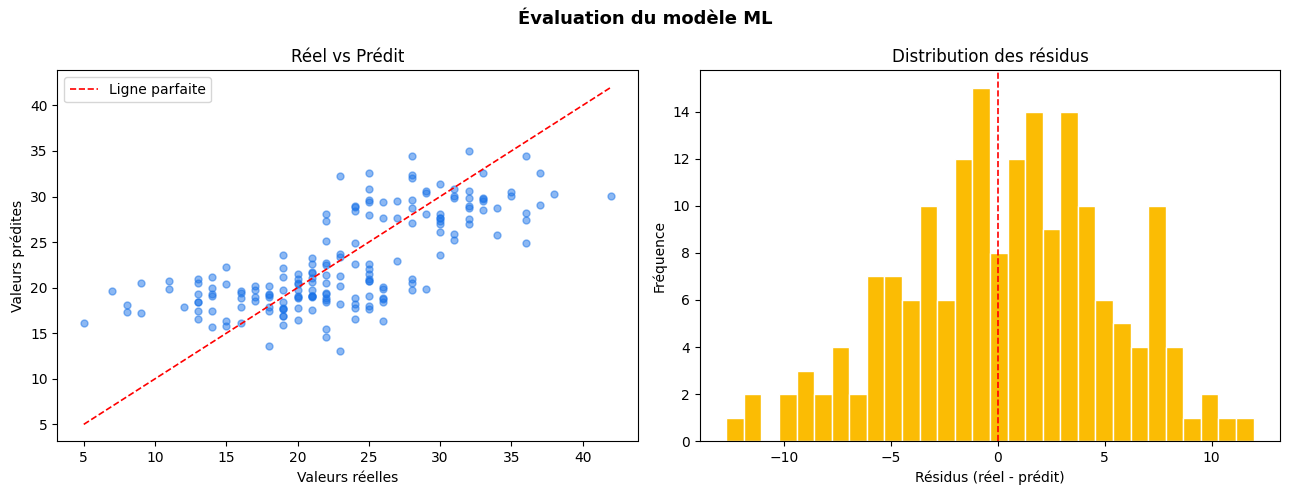

  Les deux graphiques montrent que le modèle est capable de capturer la tendance des  ventes avec une précision acceptable.


In [77]:
from matplotlib import pyplot as plt


print("\n" + "=" * 150)
print("  2.7  GRAPHIQUE PRÉDICTIONS VS RÉELS")
print("=" * 150)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Évaluation du modèle ML", fontsize=13, fontweight="bold")

# Scatter : réel vs prédit
axes[0].scatter(y_test, predictions, alpha=0.5, color="#1a73e8", s=25)
lim = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
axes[0].plot(lim, lim, "r--", linewidth=1.2, label="Ligne parfaite")
axes[0].set_xlabel("Valeurs réelles")
axes[0].set_ylabel("Valeurs prédites")
axes[0].set_title("Réel vs Prédit")
axes[0].legend()

# Résidus
residus = y_test - predictions
axes[1].hist(residus, bins=30, color="#fbbc04", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Résidus (réel - prédit)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des résidus")

plt.tight_layout()
plt.savefig("graphique_evaluation.png", dpi=150)
plt.show()
print("  Les deux graphiques montrent que le modèle est" \
" capable de capturer la tendance des  ventes avec une précision acceptable.")

2.8  Sauvegarder le modèle et le scaler ────────────────────────────────────────────────────────────────────────

In [78]:
print("\n" + "=" * 150)
print("  2.8  SAUVEGARDE DU MODÈLE")
print("=" * 150)

joblib.dump(model, "model.pkl")
joblib.dump({
    "mae": mae,
    "rmse": rmse,
    "r2": r2
}, "metriques.pkl")

print("  model.pkl     ✓")
print("  metriques.pkl ✓")



  2.8  SAUVEGARDE DU MODÈLE
  model.pkl     ✓
  metriques.pkl ✓


Objectif : préparer les données, normaliser, entraîner
           le modèle, évaluer avec MAE / RMSE / R².